# Paper Figures — Ablations & Supplementary

Supporting figures: k-mer scale, linear probe, pooling robustness, canonical k-mers, PCA, AUROC/MCC concordance, truncation, efficiency.

In [12]:
FM_COLORS = {'NTv3':'#2563EB','HyenaDNA':'#D97706','DNABERT-2':'#059669','Caduceus':'#7C3AED','Evo2':'#F59E0B'}
KMER_COLOR = '#6B7280'
MODEL_LABELS = {
    'NTv3_650M_pre':                                  'NTv3 (650M)',
    'hyenadna-medium-160k-seqlen-hf':                 'HyenaDNA',
    'DNABERT-2-117M':                                 'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': 'Caduceus',
    'evo2_1b_base':                                   'Evo2 (1B)',
}
MODEL_COLOR_KEY = {
    'NTv3_650M_pre':                                  'NTv3',
    'hyenadna-medium-160k-seqlen-hf':                 'HyenaDNA',
    'DNABERT-2-117M':                                 'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': 'Caduceus',
    'evo2_1b_base':                                   'Evo2',
}
GROUP_PALETTE = {
    'EMP':'#EF4444','deep4mc':'#F97316','enhancers':'#EAB308',
    'genomic_benchmark':'#22C55E','iDHS-EL':'#06B6D4','iDNA_ABF':'#6366F1',
    'iPro-WAEL':'#EC4899','mouse':'#14B8A6','prom':'#A855F7',
    'splice':'#F43F5E','tf':'#0EA5E9','virus':'#84CC16',
}

def task_group(name): return name.split('/')[0]
def savefig(name):
    p = FIG_DIR / name; plt.savefig(p, bbox_inches='tight'); print(f'Saved -> {p}')

print('Setup complete.')

Setup complete.


## Load data

In [13]:
rf      = pd.read_csv(RESULTS / 'classification/records_rf.csv')
lp      = pd.read_csv(RESULTS / 'classification/records_linear_probe.csv')
pca     = pd.read_csv(RESULTS / 'classification/records_pca.csv')
ck      = pd.read_csv(RESULTS / 'classification/records_canonical_kmer.csv')
dec     = pd.read_csv(RESULTS / 'decomposition/records_decomposition.csv')
auc_con = pd.read_csv(RESULTS / 'analysis/auroc_consistency.csv')
eff_gpu = pd.read_csv(RESULTS / 'efficiency/efficiency_gpu_parallel.csv')
trunc   = pd.read_csv(RESULTS / 'classification/truncation_analysis.csv')

rf['group']          = rf['dataset'].apply(task_group)
rf['best_kmer_MCC']  = rf[['kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].max(axis=1)
rf['best_kmer_AUROC']= rf[['kmer_k4_AUROC','kmer_k5_AUROC','kmer_k6_AUROC']].max(axis=1)

print('All data loaded.')


All data loaded.


---
## Ablation 1 — k-mer Scale: k=4,5,6 and Multiscale Concatenation

Violin + strip plots of MCC across 57 datasets.
Shows the effect of k-mer size and whether multiscale concatenation helps.

Saved -> /home/oem/genome-cgr-embedding/figures/abl1_kmer_scale.pdf


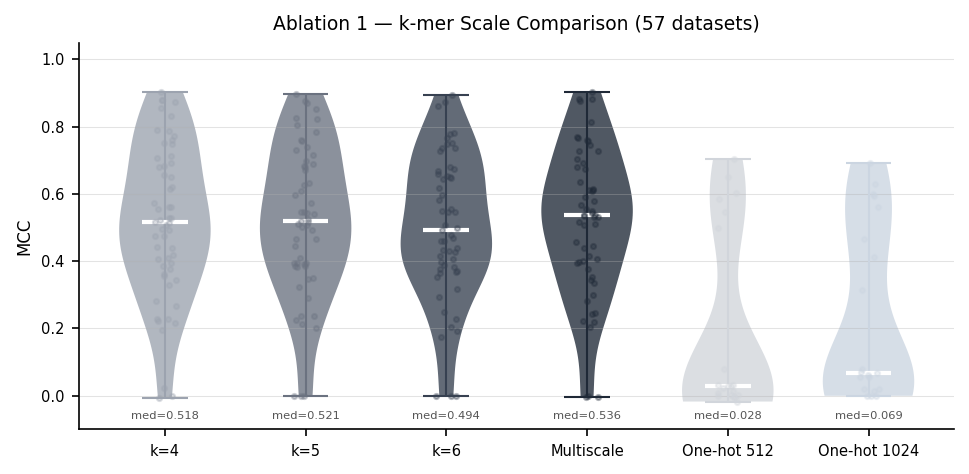

In [14]:
VARIANTS = [
    ('k=4',         'kmer_k4_MCC',       '#9CA3AF'),
    ('k=5',         'kmer_k5_MCC',       '#6B7280'),
    ('k=6',         'kmer_k6_MCC',       '#374151'),
    ('Multiscale',  'kmer_multi_k4_5_6_MCC', '#1F2937'),
    ('One-hot 512', 'onehot_512bp_MCC',  '#D1D5DB'),
    ('One-hot 1024','onehot_1024bp_MCC', '#CBD5E1'),
]

fig, ax = plt.subplots(figsize=(6.5, 3.2))

for i, (label, col, color) in enumerate(VARIANTS):
    if col not in rf.columns: continue
    vals = rf[col].dropna().values
    parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.65)
    for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.78)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
    for p in ('cbars','cmins','cmaxes'): parts[p].set_color(color); parts[p].set_linewidth(1)
    jit = np.random.default_rng(42+i).uniform(-0.08,0.08, len(vals))
    ax.scatter(np.full(len(vals),i)+jit, vals, color=color, alpha=0.35, s=6, zorder=3)
    ax.text(i, -0.07, f'med={np.median(vals):.3f}', ha='center', fontsize=5.5, color='#555')

ax.set_xticks(range(len(VARIANTS)))
ax.set_xticklabels([v[0] for v in VARIANTS])
ax.set_ylabel('MCC')
ax.set_ylim(-0.1, 1.05)
ax.set_title('Ablation 1 — k-mer Scale Comparison (57 datasets)', fontsize=9)

plt.tight_layout()
savefig('abl1_kmer_scale.pdf')
plt.show()


---
## Ablation 2 — Linear Probe vs. Random Forest

Paired scatter: RF MCC vs. linear probe MCC for FM models and k-mer baselines.
Points above diagonal: RF > linear probe (architecture advantage).
Points below diagonal: linear probe better (suggests redundant features).

Saved -> /home/oem/genome-cgr-embedding/figures/abl2_linear_probe.pdf


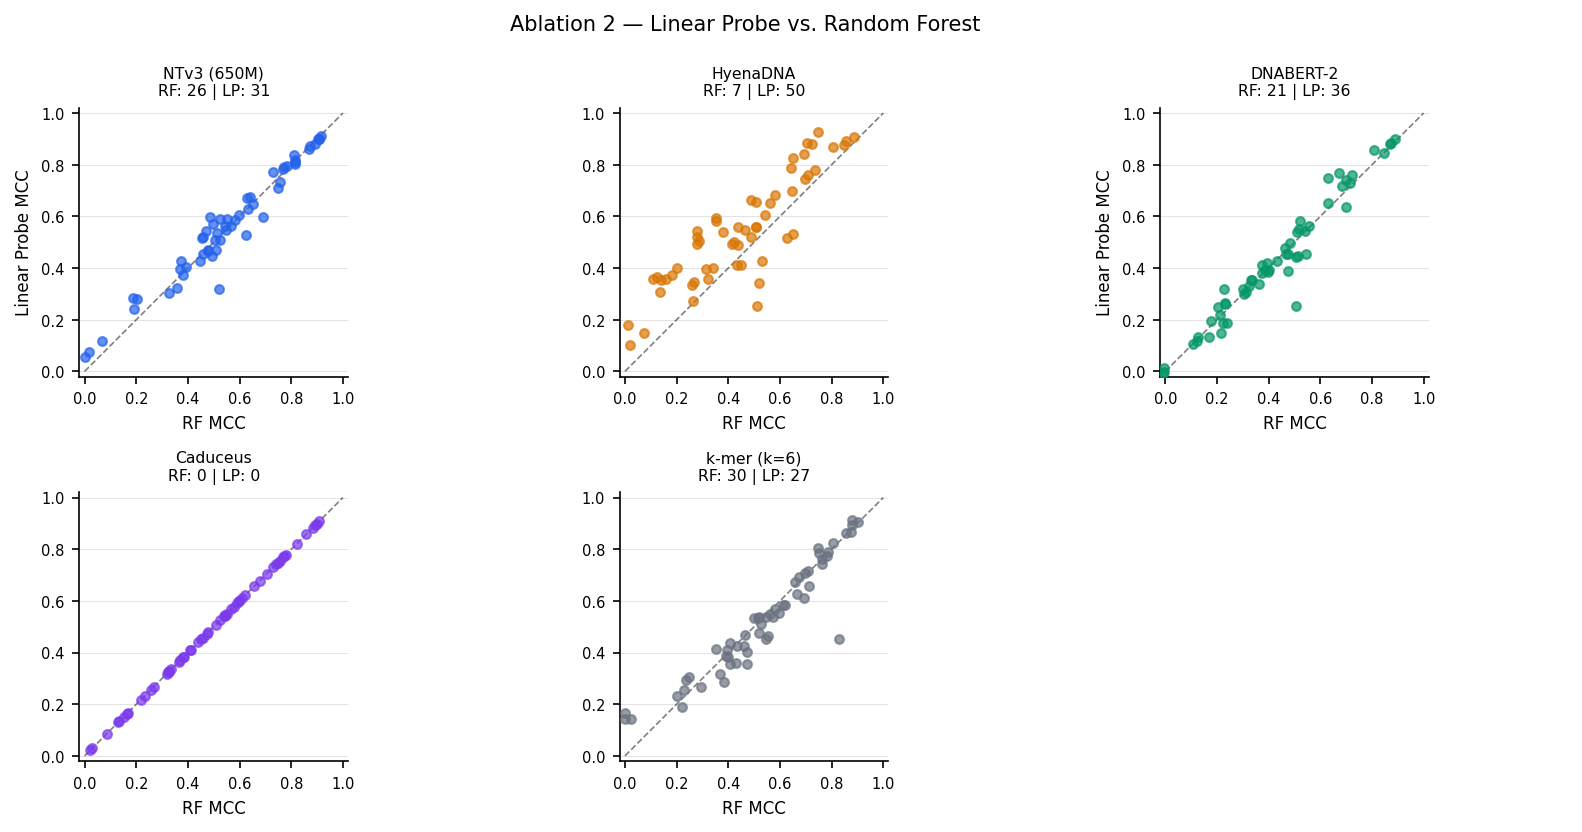

In [15]:
merged_lp = rf[['dataset','best_kmer_MCC',
                'fm_NTv3_650M_pre_MCC',
                'fm_hyenadna-medium-160k-seqlen-hf_MCC',
                'fm_DNABERT-2-117M_MCC',
                'fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC',
                'fm_evo2_1b_base_MCC']].merge(
    lp[['dataset','lp_kmer_k6_MCC',
        'lp_fm_NTv3_650M_pre_MCC__pool_max',
        'lp_fm_hyenadna-medium-160k-seqlen-hf_MCC',
        'lp_fm_DNABERT-2-117M_MCC']],
    on='dataset')

comps = [
    ('fm_NTv3_650M_pre_MCC',                  'lp_fm_NTv3_650M_pre_MCC__pool_max',       'NTv3 (650M)',  FM_COLORS['NTv3']),
    ('fm_hyenadna-medium-160k-seqlen-hf_MCC', 'lp_fm_hyenadna-medium-160k-seqlen-hf_MCC','HyenaDNA',     FM_COLORS['HyenaDNA']),
    ('fm_DNABERT-2-117M_MCC',                 'lp_fm_DNABERT-2-117M_MCC',                'DNABERT-2',    FM_COLORS['DNABERT-2']),
    ('fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC', 'fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC', 'Caduceus', FM_COLORS['Caduceus']),
    ('best_kmer_MCC',                         'lp_kmer_k6_MCC',                          'k-mer (k=6)',  KMER_COLOR),
]

fig, axes = plt.subplots(2, 3, figsize=(11.2, 5.5))
axes = axes.flatten()
fig.suptitle('Ablation 2 — Linear Probe vs. Random Forest', fontsize=10, y=0.995)

for ax, (rc, lc, label, color) in zip(axes[:5], comps):
    if lc in merged_lp.columns:
        x = merged_lp[rc].values
        y = merged_lp[lc].values
        valid = ~(np.isnan(x) | np.isnan(y))
        ax.scatter(x[valid], y[valid], color=color, alpha=0.7, s=18, zorder=3)
        ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
        rf_wins = int((x[valid] > y[valid]).sum())
        lp_wins = int((y[valid] > x[valid]).sum())
        title = label + '\nRF: ' + str(rf_wins) + ' | LP: ' + str(lp_wins)
        ax.set_title(title, fontsize=7.5)
        ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
        ax.set_xlabel('RF MCC')
    else:
        ax.text(0.5,0.5,'(no LP data)', ha='center', va='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])

# Hide the 6th subplot
axes[5].axis('off')

axes[0].set_ylabel('Linear Probe MCC')
axes[2].set_ylabel('Linear Probe MCC')

plt.tight_layout()
savefig('abl2_linear_probe.pdf')
plt.show()

---
## Ablation 3 — Decomposition Robustness: Pooling Strategy (NTv3)

Ridge R² for NTv3 under mean/max/CLS pooling across k=4,5,6.
Shows that the k-mer explainability of FM embeddings is consistent across pooling methods.

Saved -> /home/oem/genome-cgr-embedding/figures/abl3_pooling_robustness.pdf


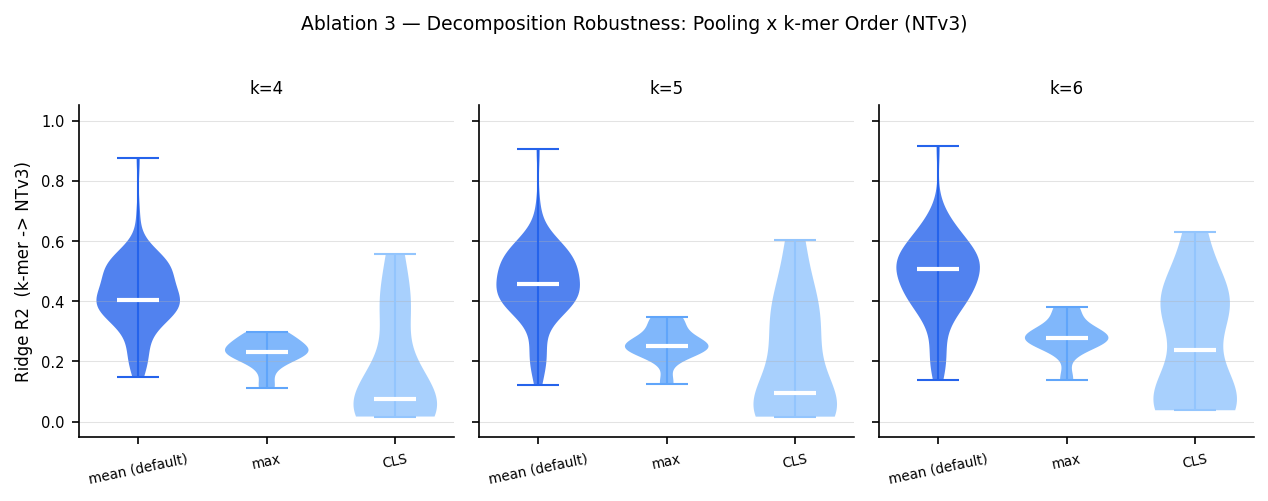

In [16]:
model = 'NTv3_650M_pre'
configs = [
    ('mean (default)', 'ridge_k{k}_' + model + '_R2',                         '#2563EB'),
    ('max',            'ridge_k{k}_' + model + '_R2__pool_max__map_ridge',     '#60A5FA'),
    ('CLS',            'ridge_k{k}_' + model + '_R2__pool_cls__map_ridge',     '#93C5FD'),
]
ks = [4, 5, 6]

fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.2), sharey=True)
fig.suptitle('Ablation 3 — Decomposition Robustness: Pooling x k-mer Order (NTv3)', fontsize=9, y=1.02)

for ax, k in zip(axes, ks):
    for i, (pool_label, col_tmpl, color) in enumerate(configs):
        col = col_tmpl.format(k=k)
        if col not in dec.columns: continue
        vals = dec[col].dropna().values
        parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.65)
        for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.8)
        parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
        for p in ('cbars','cmins','cmaxes'): parts[p].set_color(color); parts[p].set_linewidth(1)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels([c[0] for c in configs], fontsize=6.5, rotation=12)
    ax.set_title('k=' + str(k), fontsize=8)
    ax.set_ylim(-0.05,1.05)

axes[0].set_ylabel('Ridge R2  (k-mer -> NTv3)')
plt.tight_layout()
savefig('abl3_pooling_robustness.pdf')
plt.show()


---
## Ablation 4 — Canonical vs. Standard k-mers

Paired scatter: canonical (reverse-complement normalised) vs. standard k-mer MCC.
Checks whether strand symmetry in k-mer counting matters for classification.

Saved -> /home/oem/genome-cgr-embedding/figures/abl4_canonical_kmer.pdf


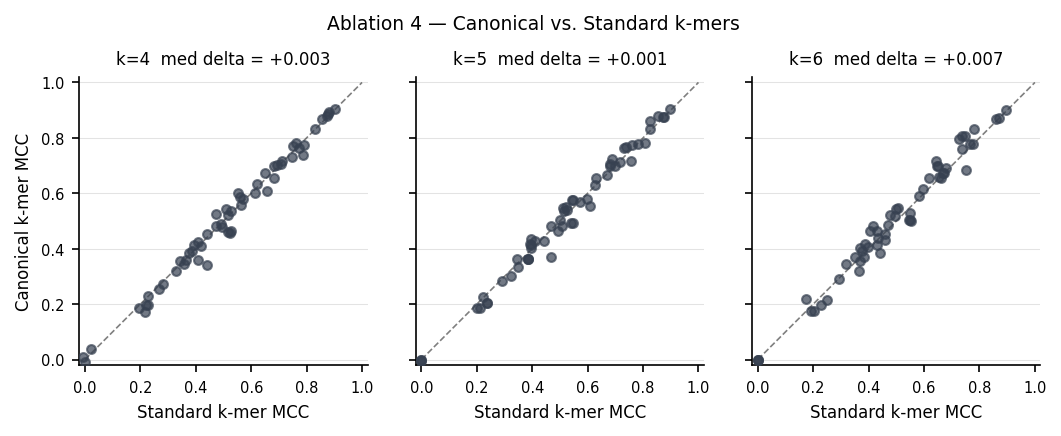

In [17]:
merged_ck = rf[['dataset','kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].merge(
    ck[['dataset','ckmer_k4_MCC','ckmer_k5_MCC','ckmer_k6_MCC']], on='dataset')

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharex=True, sharey=True)
fig.suptitle('Ablation 4 — Canonical vs. Standard k-mers', fontsize=9, y=1.02)

for ax, k in zip(axes, [4,5,6]):
    x = merged_ck[f'kmer_k{k}_MCC'].values
    y = merged_ck[f'ckmer_k{k}_MCC'].values
    ax.scatter(x, y, color='#374151', alpha=0.7, s=18, zorder=3)
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
    diff = float(np.median(y - x))
    ax.set_title('k=' + str(k) + '  med delta = ' + f'{diff:+.3f}', fontsize=8)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
    ax.set_xlabel('Standard k-mer MCC')

axes[0].set_ylabel('Canonical k-mer MCC')
plt.tight_layout()
savefig('abl4_canonical_kmer.pdf')
plt.show()


---
## Ablation 5 — PCA Dimensionality Reduction

Full-dim vs. PCA-compressed features for FM and k-mer methods.
Tests whether k=6 (4096 dims) benefits from dimensionality reduction.

Saved -> /home/oem/genome-cgr-embedding/figures/abl5_pca.pdf


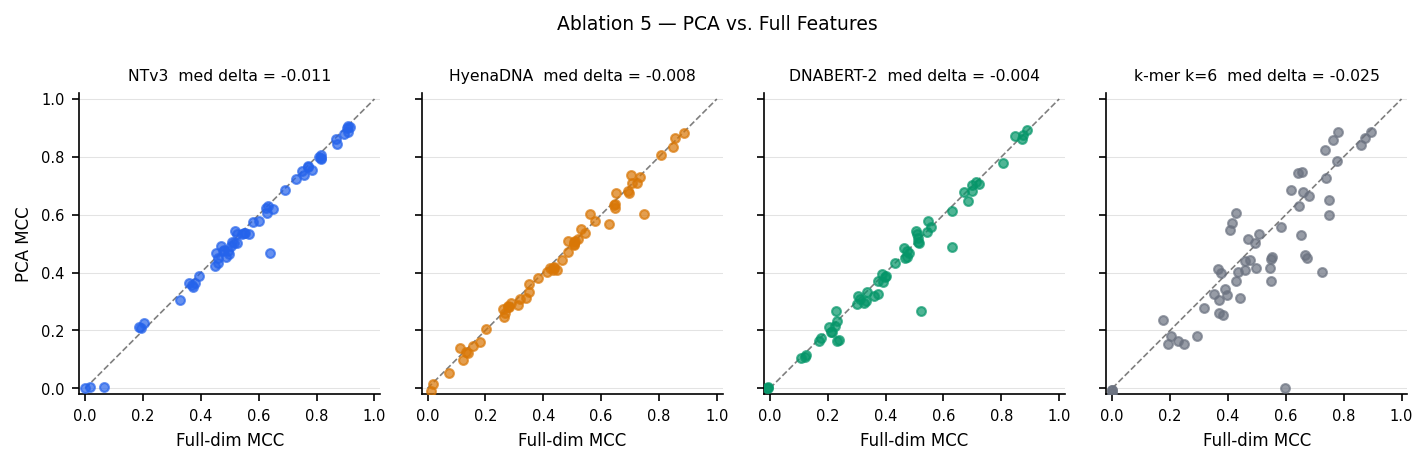

In [18]:
merged_pca = rf[['dataset',
                 'fm_NTv3_650M_pre_MCC',
                 'fm_hyenadna-medium-160k-seqlen-hf_MCC',
                 'fm_DNABERT-2-117M_MCC',
                 'kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].merge(
    pca[['dataset',
         'pca_fm_NTv3_650M_pre_MCC',
         'pca_fm_hyenadna-medium-160k-seqlen-hf_MCC',
         'pca_fm_DNABERT-2-117M_MCC',
         'pca_kmer_k4_MCC','pca_kmer_k5_MCC','pca_kmer_k6_MCC']],
    on='dataset')

pairs = [
    ('fm_NTv3_650M_pre_MCC',                  'pca_fm_NTv3_650M_pre_MCC',                  'NTv3',     FM_COLORS['NTv3']),
    ('fm_hyenadna-medium-160k-seqlen-hf_MCC', 'pca_fm_hyenadna-medium-160k-seqlen-hf_MCC', 'HyenaDNA', FM_COLORS['HyenaDNA']),
    ('fm_DNABERT-2-117M_MCC',                 'pca_fm_DNABERT-2-117M_MCC',                 'DNABERT-2',FM_COLORS['DNABERT-2']),
    ('kmer_k6_MCC',                           'pca_kmer_k6_MCC',                           'k-mer k=6',KMER_COLOR),
]

fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.8), sharex=True, sharey=True)
fig.suptitle('Ablation 5 — PCA vs. Full Features', fontsize=9, y=1.02)

for ax, (fc, pc_col, label, color) in zip(axes, pairs):
    x = merged_pca[fc].values
    y = merged_pca[pc_col].values
    valid = ~(np.isnan(x) | np.isnan(y))
    ax.scatter(x[valid], y[valid], color=color, alpha=0.7, s=18, zorder=3)
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
    diff = float(np.median((y-x)[valid]))
    ax.set_title(label + '  med delta = ' + f'{diff:+.3f}', fontsize=7.5)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
    ax.set_xlabel('Full-dim MCC')

axes[0].set_ylabel('PCA MCC')
plt.tight_layout()
savefig('abl5_pca.pdf')
plt.show()


---
## Ablation 6 — MCC vs. AUROC Ranking Concordance

Scatter of ΔMCC vs ΔAUROC (FM − best k-mer) across 57 datasets.
Discordant points (upper-left or lower-right) expose tasks where metrics disagree.

Saved -> /home/oem/genome-cgr-embedding/figures/abl6_concordance.pdf


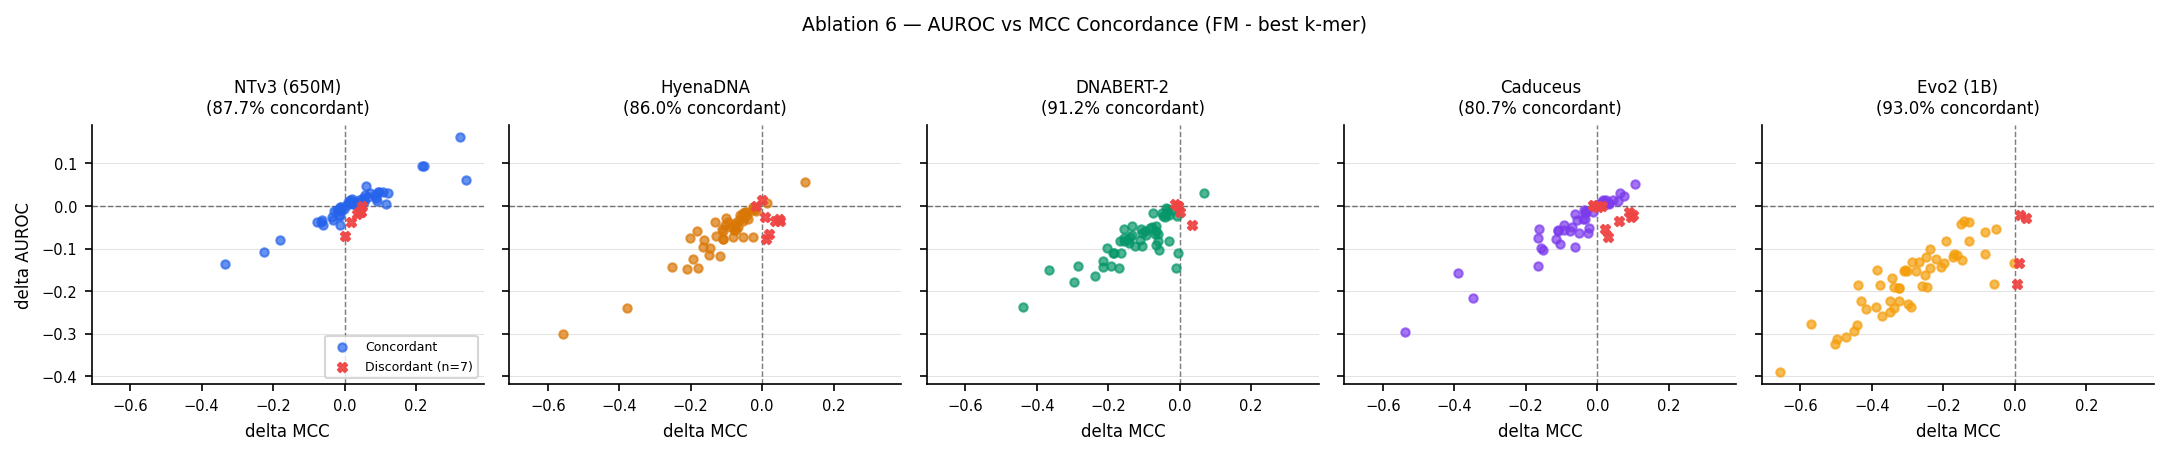

In [19]:
MODELS = [
    ('NTv3_650M_pre',              'NTv3 (650M)',  FM_COLORS['NTv3']),
    ('hyenadna-medium-160k-seqlen-hf','HyenaDNA',  FM_COLORS['HyenaDNA']),
    ('DNABERT-2-117M',             'DNABERT-2',    FM_COLORS['DNABERT-2']),
    ('caduceus-ph_seqlen-131k_d_model-256_n_layer-16', 'Caduceus', FM_COLORS['Caduceus']),
    ('evo2_1b_base',               'Evo2 (1B)',    FM_COLORS['Evo2']),
]

fig, axes = plt.subplots(1, 5, figsize=(14.5, 2.9), sharex=True, sharey=True)
fig.suptitle('Ablation 6 — AUROC vs MCC Concordance (FM - best k-mer)', fontsize=9, y=1.02)

for ax, (mkey, label, color) in zip(axes, MODELS):
    mcc_col = f'fm_{mkey}_MCC'
    auroc_col = f'fm_{mkey}_AUROC'
    if mcc_col in rf.columns and auroc_col in rf.columns:
        dm  = (rf[mcc_col] - rf['best_kmer_MCC']).values
        da  = (rf[auroc_col] - rf['best_kmer_AUROC']).values
        conc = ((dm > 0) & (da > 0)) | ((dm < 0) & (da < 0))

        ax.scatter(dm[ conc], da[ conc], color=color,    alpha=0.7, s=16, zorder=3, label='Concordant')
        ax.scatter(dm[~conc], da[~conc], color='#EF4444', alpha=0.9, s=20,
                   marker='X', zorder=4, label='Discordant (n=' + str((~conc).sum()) + ')')
        ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
        ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
        pct = conc.mean()*100
        ax.set_title(label + '\n(' + f'{pct:.1f}' + '% concordant)', fontsize=8)
        ax.set_xlabel('delta MCC')
        if ax == axes[0]:
            ax.legend(fontsize=6, loc='lower right')

axes[0].set_ylabel('delta AUROC')
plt.tight_layout()
savefig('abl6_concordance.pdf')
plt.show()

---
## Ablation 7 — Computational Efficiency: GPU FLOPs (NTv3)

NTv3 GPU FLOPs per sequence as a function of sequence length.
Illustrates the quadratic cost of transformer attention vs. linear k-mer counting.

Saved -> /home/oem/genome-cgr-embedding/figures/abl7_efficiency.pdf


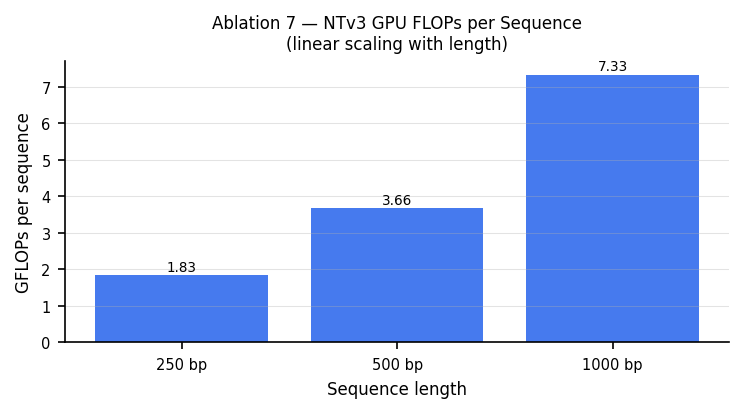

In [20]:
eff_ntv3 = eff_gpu[eff_gpu['method'] == 'fm_NTv3_650M_pre'].copy()

fig, ax = plt.subplots(figsize=(5.0, 2.8))
seq_labels = [str(int(s)) + ' bp' for s in eff_ntv3['seq_len']]
bars = ax.bar(seq_labels, eff_ntv3['GFLOPS_per_seq'],
              color=FM_COLORS['NTv3'], alpha=0.85)

for bar, val in zip(bars, eff_ntv3['GFLOPS_per_seq']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', va='bottom', fontsize=6.5)

ax.set_ylabel('GFLOPs per sequence')
ax.set_xlabel('Sequence length')
ax.set_title('Ablation 7 — NTv3 GPU FLOPs per Sequence\n(linear scaling with length)', fontsize=8)
plt.tight_layout()
savefig('abl7_efficiency.pdf')
plt.show()


---
## Ablation 8 — FM Tokenization Truncation Analysis

Per-model distribution of truncation rates across 57 datasets.
Verifies that FM results are not confounded by sequence truncation.

In [21]:
print(trunc.columns.tolist())
print(trunc.head(3))


['model', 'dataset', 'split', 'max_length', 'n_sequences', 'n_truncated', 'truncation_rate', 'mean_tokens', 'max_tokens', 'fraction_retained_mean']
                       model            dataset  split  max_length  \
0  InstaDeepAI/NTv3_650M_pre       EMP/Yeast_H3  train       32768   
1  InstaDeepAI/NTv3_650M_pre       EMP/Yeast_H3   test       32768   
2  InstaDeepAI/NTv3_650M_pre  EMP/Yeast_H3K14ac  train       32768   

   n_sequences  n_truncated  truncation_rate  mean_tokens  max_tokens  \
0        10475            0              0.0   499.961814         500   
1         4490            0              0.0   500.000000         500   
2        23133            0              0.0   499.980504         500   

   fraction_retained_mean  
0                     1.0  
1                     1.0  
2                     1.0  


Saved -> /home/oem/genome-cgr-embedding/figures/abl8_truncation.pdf


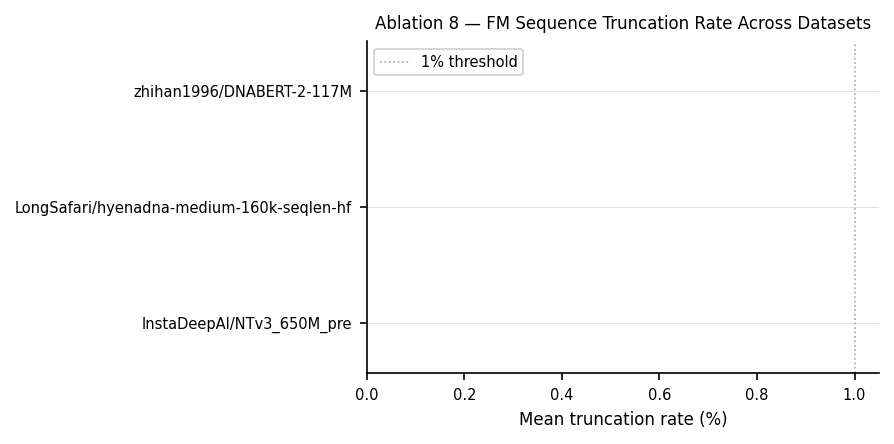

In [22]:
trunc_grp = (trunc.groupby('model')['truncation_rate']
             .agg(mean='mean', median='median', max='max')
             .reset_index())

colors_t = [FM_COLORS.get(MODEL_COLOR_KEY.get(m,''), '#888') for m in trunc_grp['model']]
mlabels  = [MODEL_LABELS.get(m, m) for m in trunc_grp['model']]

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.barh(mlabels, trunc_grp['mean'] * 100, color=colors_t, alpha=0.85, height=0.6)
ax.axvline(1, color='gray', ls=':', lw=0.8, alpha=0.7, label='1% threshold')
ax.set_xlabel('Mean truncation rate (%)')
ax.set_title('Ablation 8 — FM Sequence Truncation Rate Across Datasets', fontsize=8)
ax.legend(fontsize=7)
plt.tight_layout()
savefig('abl8_truncation.pdf')
plt.show()

---
## Ablation 9 — Caduceus vs. NTv3: Performance Across Dataset Groups

Violin plots comparing Caduceus and NTv3 MCC across all 12 dataset groups.
Exposes task categories where each model excels.

Saved -> /home/oem/genome-cgr-embedding/figures/abl9_caduceus_vs_ntv3.pdf


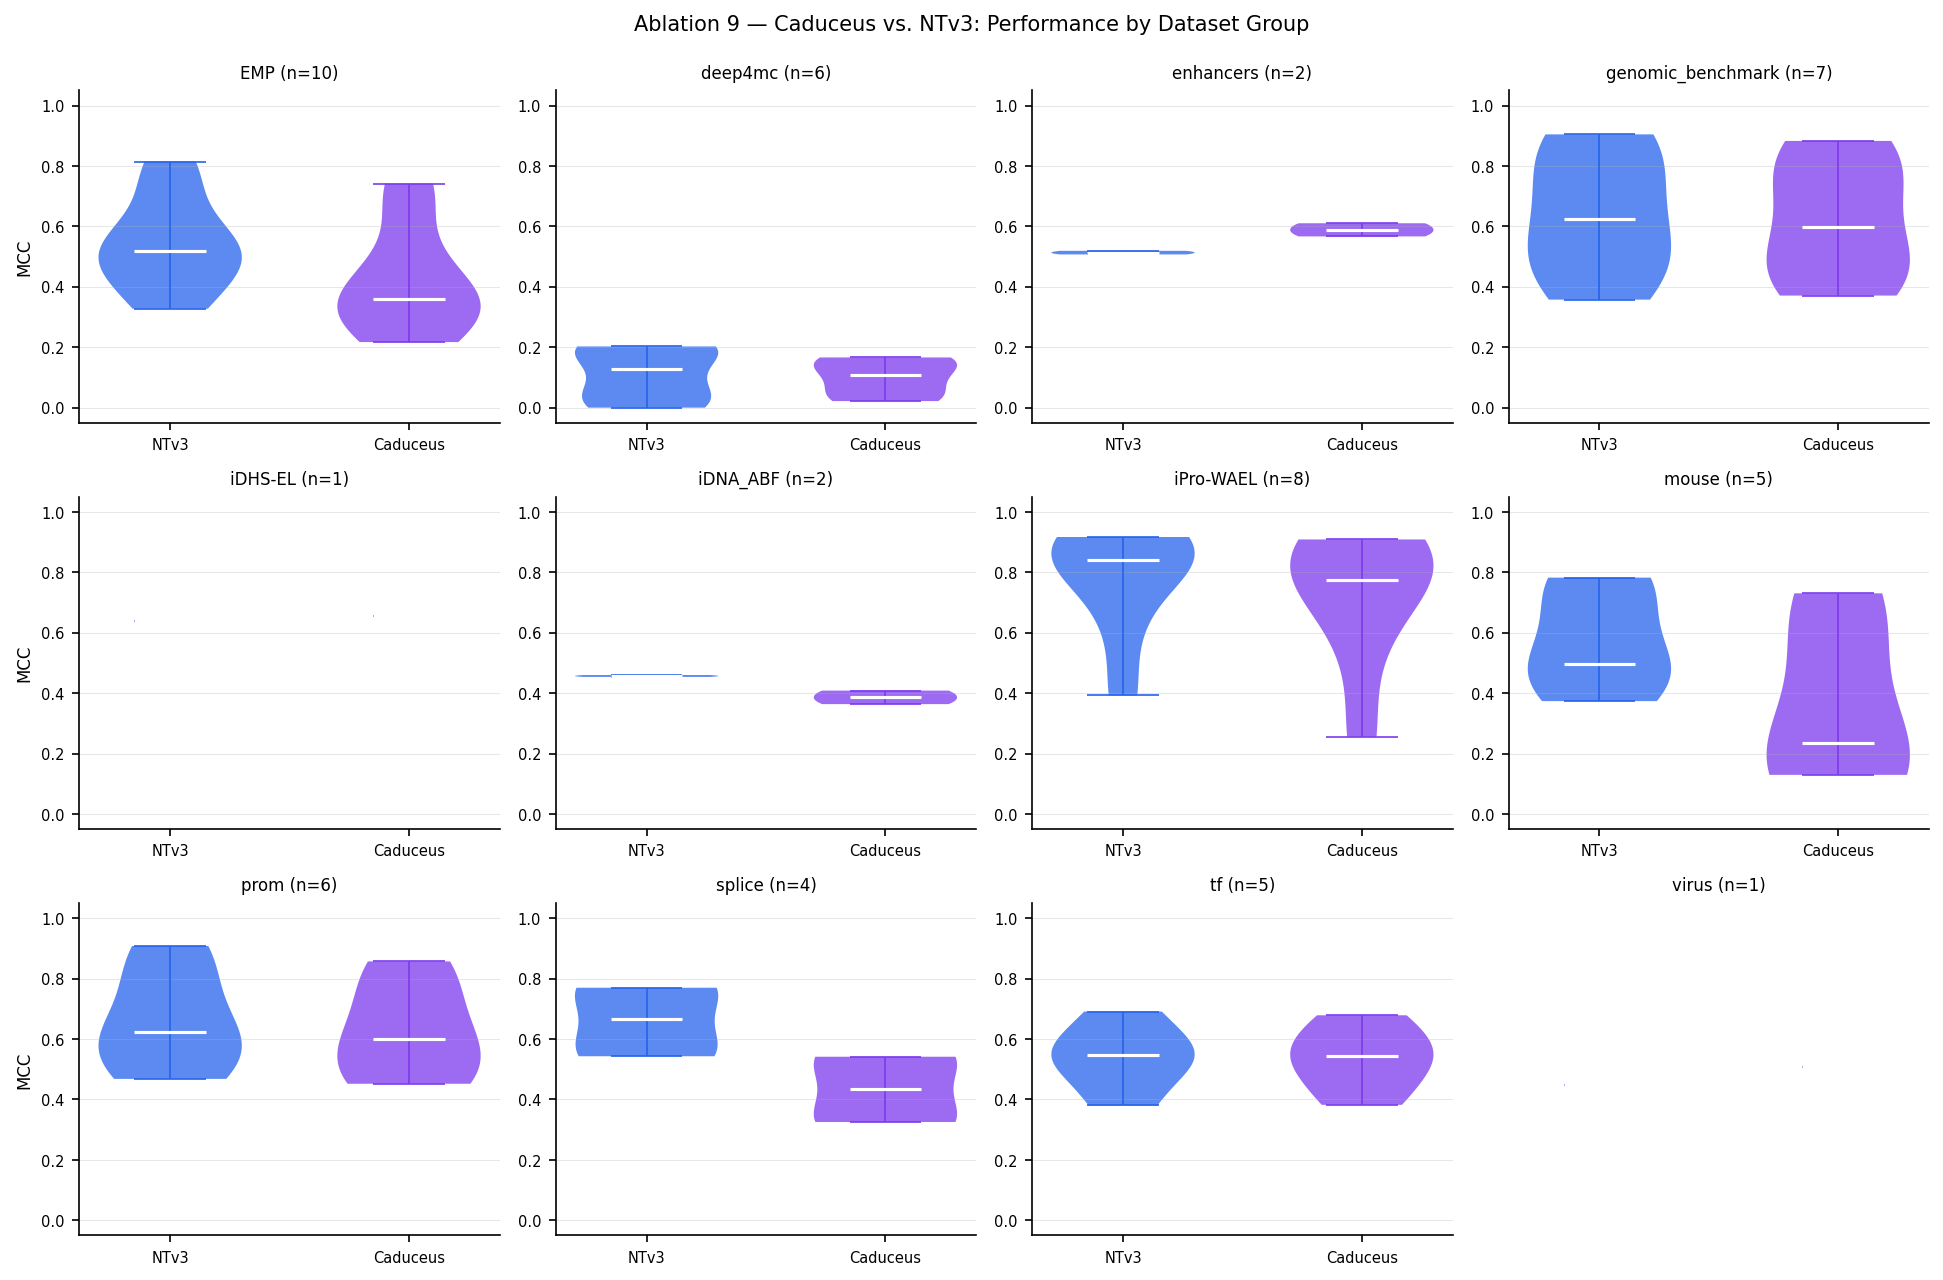

In [23]:
groups_ordered = sorted(rf['group'].unique())
fig, axes = plt.subplots(3, 4, figsize=(13.0, 8.5))
axes = axes.flatten()
fig.suptitle('Ablation 9 — Caduceus vs. NTv3: Performance by Dataset Group', fontsize=10, y=0.995)

for ax, group in zip(axes, groups_ordered):
    grp_data = rf[rf['group'] == group]
    models_data = [
        (grp_data['fm_NTv3_650M_pre_MCC'].dropna().values, 'NTv3', FM_COLORS['NTv3']),
        (grp_data['fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC'].dropna().values, 'Caduceus', FM_COLORS['Caduceus']),
    ]
    
    for i, (vals, label, color) in enumerate(models_data):
        if len(vals) > 0:
            parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.6)
            for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.75)
            parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(1.5)
            for p in ('cbars','cmins','cmaxes'): parts[p].set_color(color); parts[p].set_linewidth(0.8)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['NTv3', 'Caduceus'], fontsize=7)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('MCC' if ax in axes[::4] else '')
    ax.set_title(group + f' (n={len(grp_data)})', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide last empty subplot
axes[-1].axis('off')

plt.tight_layout()
savefig('abl9_caduceus_vs_ntv3.pdf')
plt.show()

---
## Ablation 10 — Evo2 Performance Analysis

Evo2 MCC distribution and per-dataset comparison with top performers.
Identifies tasks where Evo2 succeeds/struggles despite larger model size.

Saved -> /home/oem/genome-cgr-embedding/figures/abl10_evo2_analysis.pdf


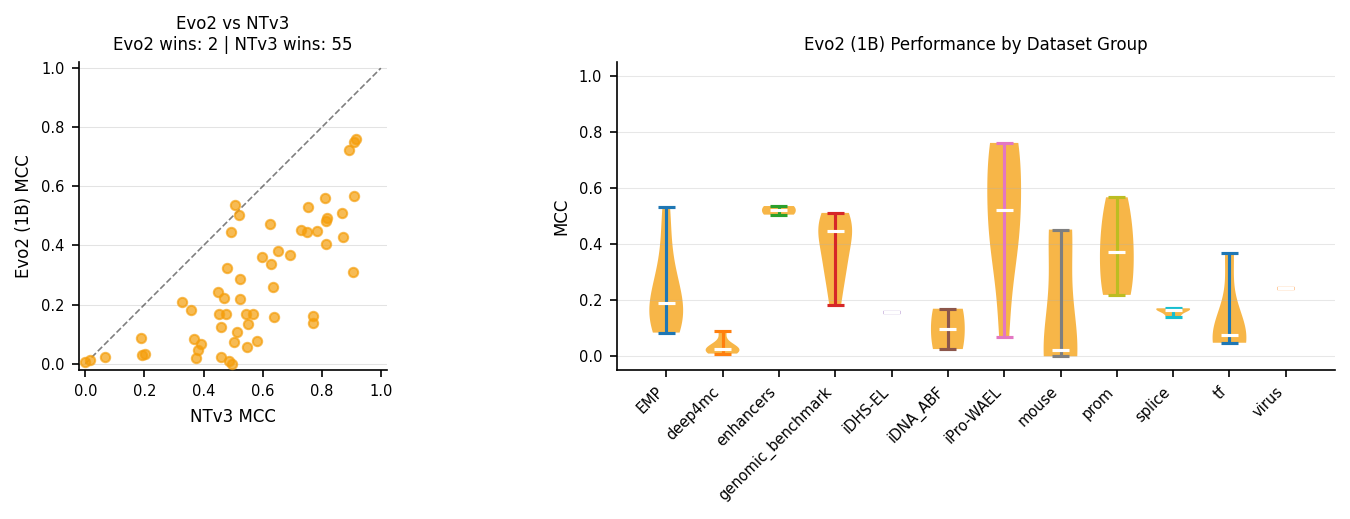

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.5))

# Left: Evo2 vs NTv3 scatter
ax = axes[0]
evo2_vals = rf['fm_evo2_1b_base_MCC'].dropna().values
ntv3_vals = rf.loc[rf['fm_evo2_1b_base_MCC'].notna(), 'fm_NTv3_650M_pre_MCC'].values
ax.scatter(ntv3_vals, evo2_vals, color=FM_COLORS['Evo2'], alpha=0.7, s=20, zorder=3)
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
evo2_wins = int((evo2_vals > ntv3_vals).sum())
ntv3_wins = int((ntv3_vals > evo2_vals).sum())
ax.set_title(f'Evo2 vs NTv3\nEvo2 wins: {evo2_wins} | NTv3 wins: {ntv3_wins}', fontsize=8)
ax.set_xlabel('NTv3 MCC')
ax.set_ylabel('Evo2 (1B) MCC')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect('equal')

# Right: Per-group violin plot
ax = axes[1]
evo2_by_group = [rf[rf['group']==g]['fm_evo2_1b_base_MCC'].dropna().values for g in groups_ordered]
positions = range(len(groups_ordered))
for i, (vals, group) in enumerate(zip(evo2_by_group, groups_ordered)):
    if len(vals) > 0:
        parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.6)
        for pc in parts['bodies']: pc.set_facecolor(FM_COLORS['Evo2']); pc.set_alpha(0.75)
        parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(1.5)

ax.set_xticks(range(len(groups_ordered)))
ax.set_xticklabels(groups_ordered, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('MCC')
ax.set_title('Evo2 (1B) Performance by Dataset Group', fontsize=8)
ax.set_ylim(-0.05, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig('abl10_evo2_analysis.pdf')
plt.show()